In [81]:
#Lab 07
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage.feature import hog
from skimage import exposure


# FUNCTIONS ----------------------------------------------------------------------------------------
# Both LoadImage and GetSobelFeatures are from assignment 1: modified a bit
def LoadImage(path, size=(256, 256)):
    img = cv2.imread(path)
    img = cv2.resize(img, size)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = img.astype(np.float32) / 255.0
    return img

def GetSobelFeatures(img):
    # Compute x and y gradients using Sobel
    Gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    Gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

    # Gradient magnitude and orientation
    M = np.sqrt(Gx ** 2 + Gy ** 2)
    Theta = np.arctan2(Gy, Gx)  # in radians

    return Gx, Gy, M, Theta

def plot_images_grid(images, titles, cols=4, figsize=(12,6), heatmap=False):
    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=figsize)

    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(rows, cols, i+1)
        plt.imshow(img, cmap='viridis' if heatmap else 'gray')
        plt.title(title)
        plt.axis("off")
        if heatmap:
            plt.colorbar()
    plt.tight_layout()
    plt.show()

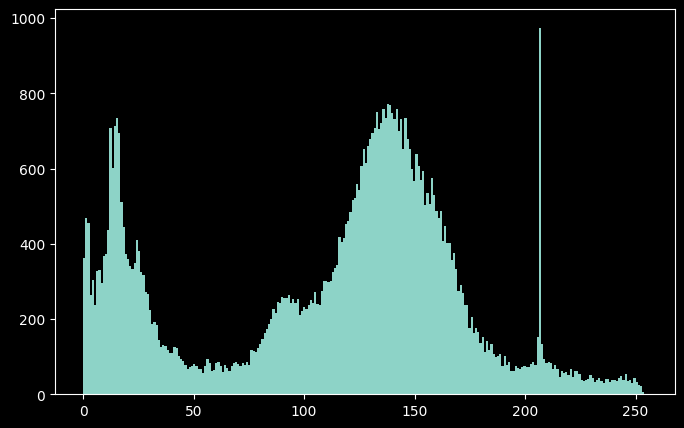

In [82]:
img = LoadImage('dark_object_light_background.jpg')
img = (img*255).astype(np.uint8)
plt.figure(figsize=(8,5))
plt.hist(img.ravel(), bins=256, range=(0,255))
plt.show()


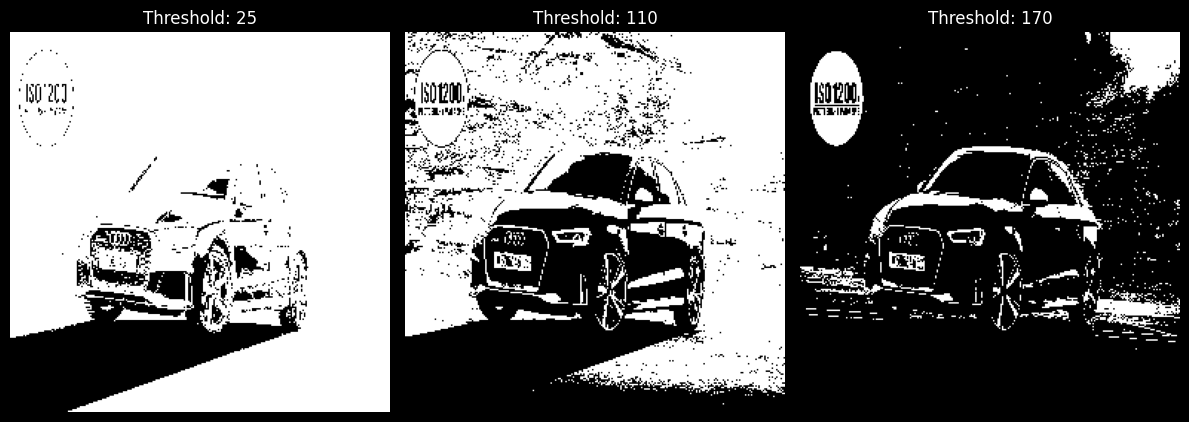

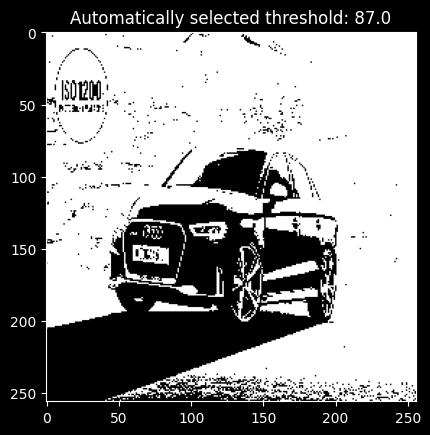

In [83]:
thresholds = [25, 110, 170]
#create binary mask
def binary_mask(t, img):
    test = img.copy()
    h,w = img.shape
    for y in range(h):
        for x in range(w):
            pixel = img[y,x]
            test[y,x] = 255 if (pixel > t) else 0
    return test

# create binary mask
binary_mask_list = []
t_names = []
for t in thresholds:
    binary_mask_list.append(binary_mask(t, img))
    t_names.append(f"Threshold: {t}")
plot_images_grid(binary_mask_list, t_names, cols=3)

#Otsus threshold
retval, dst = cv2.threshold(img, 0,255, cv2.THRESH_OTSU)

plt.figure()
plt.imshow(dst, cmap='gray')
plt.title(f"Automatically selected threshold: {retval}")
plt.show()


In [84]:
#Otsus threshold
def otsu_threshold(img):
    best_threshold = 0
    best_variance = float('inf')

    pixels = img.ravel()
    total_pixels = len(pixels)

    for t in range(0,256):
        class0 = pixels[pixels < t]
        class1 = pixels[pixels >= t]

        w0 = len(class0) / total_pixels
        w1 = len(class1) / total_pixels

        var0 = np.var(class0) if len(class0) > 0 else 0
        var1 = np.var(class1) if len(class1) > 0 else 0

        intra_class_variance = w0 * var0 + w1 * var1

        if intra_class_variance < best_variance:
            best_variance = intra_class_variance
            best_threshold = t
    return best_threshold

print(otsu_threshold(img))


88


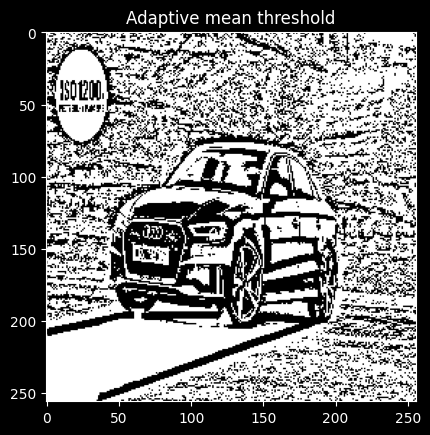

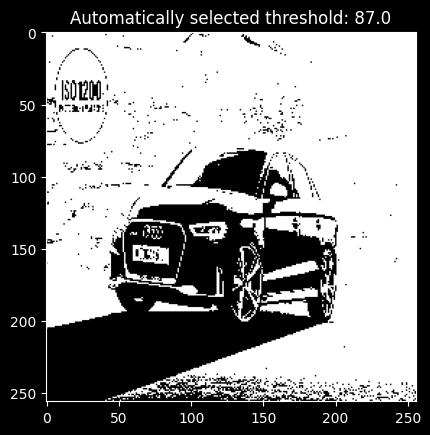

In [85]:
thresh_mean = cv2.adaptiveThreshold(
    img,
    255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    11,
    5
)
#Adaptive threshold
plt.imshow(thresh_mean, cmap='gray')
plt.title('Adaptive mean threshold')
plt.show()
plt.figure()
#Otsus Threshold
plt.imshow(dst, cmap='gray')
plt.title(f"Automatically selected threshold: {retval}")
plt.show()


Questions
1. Looking at the histogram of your test image, can you predict where Otsu’s threshold will fall? What histogram shape makes Otsu’s method work well?
    - Yes it will fall between the two peaks at 25 and 125.
    - Otsus method will work best when there are two peaks, with a valley in between them.
2. Why does global thresholding fail on images with uneven illumination, and what does adaptive thresholding do differently?
    - Global thresholding uses one single threshold for the entire image
    - adaptive thresholding compputes a locall threshold for a smaller region in the image. This makes it more robust to uneven illumintaion
3. Otsu minimises intra-class variance. Show that this is equivalent to maximising inter-class variance. Why is inter-class variance a useful segmentation criterion?
    - Inter class measures seperability: it focuses on how far aprt the averages of the foreground and background are. which can be used to seperate the background and foreground